In [1]:
%matplotlib widget
import inspect
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
import warp as wp

from sphWarpCore import *
from sphWarpCore.util import generateNeighborTestData

wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r, type(x).__name__, x))

def plot_scalar_field(ax, positions, values, title, *, cmap="viridis", marker_size=2, domain=None):
    sc = ax.scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=values.cpu(), cmap=cmap, s=marker_size)
    ax.figure.colorbar(sc, ax=ax, shrink=0.95)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
    if domain is not None:
        ax.set_xlim(domain.min[0].item(), domain.max[0].item())
        ax.set_ylim(domain.min[1].item(), domain.max[1].item())
    return sc

def make_linear_vector_field(x, y):
    return torch.stack((2.0 * x + y, -x + 0.5 * y), dim=-1)

def make_periodic_vector_field(x, y):
    return torch.stack((torch.sin(math.pi * x), torch.cos(math.pi * y)), dim=-1)

def analytic_scalar_laplacian(x, y, field_mode):
    if field_mode == "periodic_sinusoidal":
        return -math.pi ** 2 * torch.sin(math.pi * x) - math.pi ** 2 * torch.cos(math.pi * y)
    return torch.zeros_like(x)

def analytic_vector_laplacian(x, y, field_mode):
    if field_mode == "periodic_sinusoidal":
        return torch.stack((
            -math.pi ** 2 * torch.sin(math.pi * x),
            -math.pi ** 2 * torch.cos(math.pi * y),
        ), dim=-1)
    return torch.zeros((x.shape[0], 2), device=x.device, dtype=x.dtype)

def make_jittered_particles(base_positions, base_supports, base_masses, base_kinds, jitter_scale, dx):
    jittered_positions = (base_positions + jitter_scale * dx * torch.randn_like(base_positions)).contiguous()
    return ParticleState(
        positions=jittered_positions,
        supports=base_supports.contiguous(),
        masses=base_masses.contiguous(),
        densities=None,
        kinds=base_kinds,
    )

ModuleNotFoundError: No module named 'sphWarpCore.radiusSearch.compactHash.wp_compactHash'

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx ** dim

warpOnly = False
periodic = True
field_mode = "periodic_sinusoidal"  # "linear" or "periodic_sinusoidal"
mask_edge_particles = True
jitter = 0.05

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.SuperSymmetric

markerSize = 8 if warpOnly else 2
gridVisualization = False
gridResolution = 128

positions, supports, _, domain, dx = generateNeighborTestData(
    nx, targetNumNeighbors, dim, periodic, device
)

masses = torch.full((positions.shape[0],), dx ** dim, device=device, dtype=positions.dtype)
kinds = torch.zeros(positions.shape[0], device=device, dtype=torch.int32)

particles = ParticleState(
    positions=positions.contiguous(),
    supports=supports.contiguous(),
    masses=masses.contiguous(),
    densities=None,
    kinds=kinds,
)

adjacency = radiusSearchCompactHashMap(
    particles,
    domain,
    mode=SupportScheme.SuperSymmetric,
)

densities = warpOperation(
    particles,
    OperationProperties(
        kernel=kernel,
        operation=WarpOperation.Density,
        supportMode=SupportScheme.Gather,
        operationMode=OperationDirection.AllToAll,
    ),
    domain,
    adjacency=adjacency,
)
particles.densities = densities

plot_mask = torch.ones(positions.shape[0], dtype=torch.bool, device=positions.device)
if field_mode == "linear" and mask_edge_particles:
    band = 4.0 * dx
    for axis_idx in range(dim):
        plot_mask = plot_mask & (positions[:, axis_idx] > domain.min[axis_idx] + band)
        plot_mask = plot_mask & (positions[:, axis_idx] < domain.max[axis_idx] - band)

jittered_particles = make_jittered_particles(
    positions,
    supports,
    masses,
    kinds,
    jitter,
    dx,
)
jittered_adjacency = radiusSearchCompactHashMap(
    jittered_particles,
    domain,
    mode=SupportScheme.SuperSymmetric,
)
jittered_densities = warpOperation(
    jittered_particles,
    OperationProperties(
        kernel=kernel,
        operation=WarpOperation.Density,
        supportMode=SupportScheme.Gather,
        operationMode=OperationDirection.AllToAll,
    ),
    domain,
    adjacency=jittered_adjacency,
)
jittered_particles.densities = jittered_densities

apparent_area, crk_density, crk_state = computeCRKFactors(
    jittered_particles,
    domain,
    kernel,
    operationMode=OperationDirection.AllToAll,
    adjacency=jittered_adjacency,
)

/home/veldora/dev/warpSPHCore/src/sphWarpCore/radiusSearch/wp_compactHash.py:1122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  periodicity = torch.tensor(domain.periodic if domain.periodic is not None else [False] * queryParticles.positions.shape[1], device=queryParticles.positions.device)


Scalar laplacian Warp MAE: 422.92840576171875
Scalar laplacian plain jittered MAE: 0.06705869734287262
Scalar laplacian CRK MAE: 0.14674830436706543


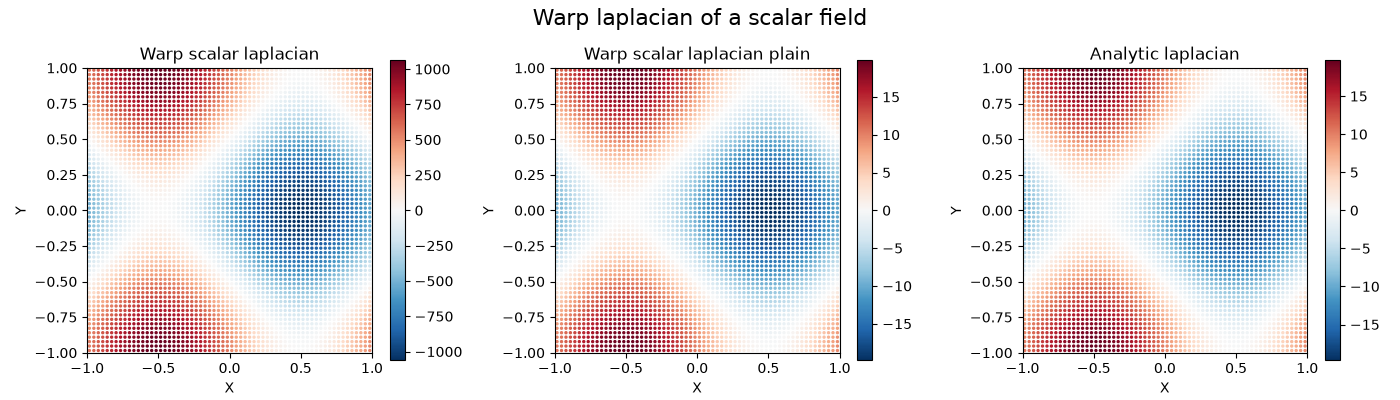

In [16]:
scalar_x = positions[:, 0]
scalar_y = positions[:, 1]
scalar_jittered_x = jittered_particles.positions[:, 0]
scalar_jittered_y = jittered_particles.positions[:, 1]

if field_mode == "periodic_sinusoidal":
    scalar_field = torch.sin(math.pi * scalar_x) + torch.cos(math.pi * scalar_y)
    scalar_field_jittered = torch.sin(math.pi * scalar_jittered_x) + torch.cos(math.pi * scalar_jittered_y)
else:
    scalar_field = 1.5 * scalar_x - 0.25 * scalar_y
    scalar_field_jittered = 1.5 * scalar_jittered_x - 0.25 * scalar_jittered_y

analytic_scalar = analytic_scalar_laplacian(scalar_x, scalar_y, field_mode)
analytic_scalar_jittered = analytic_scalar_laplacian(scalar_jittered_x, scalar_jittered_y, field_mode)

scalar_laplacian_warp = warpOperation(
    particles,
    queryValues=scalar_field,
    referenceValues=scalar_field,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=supportMode,
        operation=WarpOperation.Laplacian,
        gradientMode=GradientScheme.Symmetric,
        laplacianMode=LaplacianScheme.Naive,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=adjacency,
    domain=domain,
).squeeze()

scalar_laplacian_plain = warpOperation(
    particles,
    queryValues=scalar_field,
    referenceValues=scalar_field,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=supportMode,
        operation=WarpOperation.Laplacian,
        gradientMode=GradientScheme.Difference,
        laplacianMode=LaplacianScheme.Naive,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=adjacency,
    domain=domain,
).squeeze()

scalar_laplacian_crk = warpOperation(
    jittered_particles,
    queryValues=scalar_field_jittered,
    referenceValues=scalar_field_jittered,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=SupportScheme.SuperSymmetric,
        operation=WarpOperation.Laplacian,
        gradientMode=GradientScheme.Difference,
        laplacianMode=LaplacianScheme.Default,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=jittered_adjacency,
    domain=domain,
    crkState=crk_state,
    queryVolumes=apparent_area,
    referenceVolumes=apparent_area,
).squeeze()

scalar_laplacian_warp_error = torch.abs(scalar_laplacian_warp - analytic_scalar)
scalar_laplacian_plain_error = torch.abs(scalar_laplacian_plain - analytic_scalar_jittered)
scalar_laplacian_crk_error = torch.abs(scalar_laplacian_crk - analytic_scalar_jittered)

fig, axis = plt.subplots(1, 3, figsize=(14, 4), squeeze=False)
plot_scalar_field(axis[0, 0], positions[plot_mask], scalar_laplacian_warp[plot_mask], "Warp scalar laplacian", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[0, 1], positions[plot_mask], scalar_laplacian_plain[plot_mask], "Warp scalar laplacian plain", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[0, 2], positions[plot_mask], analytic_scalar[plot_mask], "Analytic laplacian", cmap="RdBu_r", marker_size=markerSize, domain=domain)
fig.suptitle("Warp laplacian of a scalar field", fontsize=16)
fig.tight_layout()
print("Scalar laplacian Warp MAE:", scalar_laplacian_warp_error.mean().item())
print("Scalar laplacian plain jittered MAE:", scalar_laplacian_plain_error.mean().item())
print("Scalar laplacian CRK MAE:", scalar_laplacian_crk_error.mean().item())

In [17]:
scalar_laplacian_warp.max() / scalar_laplacian_plain.max()

tensor(53.5233, device='cuda:0')

In [14]:
1/particles.masses * particles.densities * particles.supports

tensor([255.6337, 255.6337, 255.6337,  ..., 255.6337, 255.6337, 255.6337],
       device='cuda:0')

In [ ]:
vector_x = positions[:, 0]
vector_y = positions[:, 1]
vector_jittered_x = jittered_particles.positions[:, 0]
vector_jittered_y = jittered_particles.positions[:, 1]

if field_mode == "periodic_sinusoidal":
    vector_field = make_periodic_vector_field(vector_x, vector_y)
    vector_field_jittered = make_periodic_vector_field(vector_jittered_x, vector_jittered_y)
else:
    vector_field = make_linear_vector_field(vector_x, vector_y)
    vector_field_jittered = make_linear_vector_field(vector_jittered_x, vector_jittered_y)

analytic_vector = analytic_vector_laplacian(vector_x, vector_y, field_mode)
analytic_vector_jittered = analytic_vector_laplacian(vector_jittered_x, vector_jittered_y, field_mode)

vector_laplacian_warp = warpOperation(
    particles,
    queryValues=vector_field,
    referenceValues=vector_field,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=supportMode,
        operation=WarpOperation.Laplacian,
        gradientMode=GradientScheme.Difference,
        laplacianMode=LaplacianScheme.Default,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=adjacency,
    domain=domain,
)

vector_laplacian_plain = warpOperation(
    jittered_particles,
    queryValues=vector_field_jittered,
    referenceValues=vector_field_jittered,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=supportMode,
        operation=WarpOperation.Laplacian,
        gradientMode=GradientScheme.Difference,
        laplacianMode=LaplacianScheme.Default,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=jittered_adjacency,
    domain=domain,
)

vector_laplacian_crk = warpOperation(
    jittered_particles,
    queryValues=vector_field_jittered,
    referenceValues=vector_field_jittered,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=SupportScheme.SuperSymmetric,
        operation=WarpOperation.Laplacian,
        gradientMode=GradientScheme.Difference,
        laplacianMode=LaplacianScheme.Default,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=jittered_adjacency,
    domain=domain,
    crkState=crk_state,
    queryVolumes=apparent_area,
    referenceVolumes=apparent_area,
)

vector_laplacian_warp_error = torch.abs(vector_laplacian_warp - analytic_vector)
vector_laplacian_plain_error = torch.abs(vector_laplacian_plain - analytic_vector_jittered)
vector_laplacian_crk_error = torch.abs(vector_laplacian_crk - analytic_vector_jittered)

fig, axis = plt.subplots(2, 3, figsize=(15, 9), squeeze=False)
plot_scalar_field(axis[0, 0], positions[plot_mask], vector_laplacian_warp[:, 0][plot_mask], "Warp laplacian [0]", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[1, 0], positions[plot_mask], vector_laplacian_warp[:, 1][plot_mask], "Warp laplacian [1]", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[0, 1], jittered_particles.positions[plot_mask], vector_laplacian_crk[:, 0][plot_mask], "CRK laplacian [0]", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[1, 1], jittered_particles.positions[plot_mask], vector_laplacian_crk[:, 1][plot_mask], "CRK laplacian [1]", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[0, 2], jittered_particles.positions[plot_mask], vector_laplacian_plain_error.norm(dim=1)[plot_mask], "Plain error norm", cmap="magma", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[1, 2], jittered_particles.positions[plot_mask], vector_laplacian_crk_error.norm(dim=1)[plot_mask], "CRK error norm", cmap="magma", marker_size=markerSize, domain=domain)
fig.suptitle("Warp laplacian of a vector field", fontsize=16)
fig.tight_layout()
print("Vector laplacian Warp MAE:", vector_laplacian_warp_error.norm(dim=1).mean().item())
print("Vector laplacian plain jittered MAE:", vector_laplacian_plain_error.norm(dim=1).mean().item())
print("Vector laplacian CRK MAE:", vector_laplacian_crk_error.norm(dim=1).mean().item())